# JUMP → SpatialData

`cpio.read_plate` reads one plate of a Cell Painting Gallery source into a [SpatialData](https://spatialdata.scverse.org) object.
Fields of view become Images, the CellProfiler Nuclei, Cells and Cytoplasm segmentations become Labels, the wells become Shapes, and the well- and cell-level measurements become the `wells` and `cells` Tables.

Objects are Labels rather than Shapes because CellProfiler is pixel-based: it measures on masks, so a polygon would be a lossy conversion.
The gallery publishes one-pixel outlines rather than masks, so the labels are reconstructed from them and carry CellProfiler's own object numbers, which is what lets the `cells` table annotate them.

`cpg0016-jump` is the production JUMP screen, twelve imaging sites contributing plates under their own `source_N`.
This reads one compound plate from `source_4`, the same microscope as the [CPJUMP1 pilot](cpjump1.ipynb), so the two are directly comparable.

The one thing that differs from the pilot is where the well-level profile lives: `source_4` publishes it as `{plate}.parquet` rather than under a variant name, so `profile` takes a path instead of a variant.

Two wells of `cpg0016-jump`, fetched with the script beside this notebook:

```bash
for well in A01 A02; do
  python fetch.py cpg0016-jump/source_4 2021_04_26_Batch1 BR00117035 $well
done
```

In [1]:
from __future__ import annotations

import logging
import warnings
from pathlib import Path

import numpy as np
import spatialdata as sd
import spatialdata_plot  # noqa: F401
from matplotlib.colors import Normalize

import cell_painting_io as cpio

# ome-zarr logs a line per label element on read, and spatialdata-plot warns once per element it subsets out
logging.getLogger("ome_zarr").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="The table is annotating .*, which is not present")

DATA_ROOT = Path("~/data/cpg0016-jump/source_4").expanduser()
BATCH = "2021_04_26_Batch1"
PLATE = "BR00117035"


def grey(sdata, element, channel="DNA"):
    values = sd.get_pyramid_levels(sdata[element], n=0).sel(c=channel).to_numpy()
    return {
        "channel": channel,
        "cmap": "gray",
        "norm": Normalize(*np.percentile(values, [50, 99.9])),
        "colorbar": False,
    }

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sdata = cpio.read_plate(
    DATA_ROOT, BATCH, PLATE, profile=DATA_ROOT / "workspace/profiles" / BATCH / PLATE / f"{PLATE}.parquet"
)
sdata

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object
├── Images
│     ├── 'BR00117035_A01_s1_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00117035_A01_s2_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00117035_A01_s3_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00117035_A01_s4_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00117035_A01_s5_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00117035_A01_s6_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00117035_A01_s7_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00117035_A01_s8_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00117035_A01_s9_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00117035_A02_s1_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)


The nine fields of a well in the well coordinate system, then the cell masks of one field coloured by a column of the cell table.

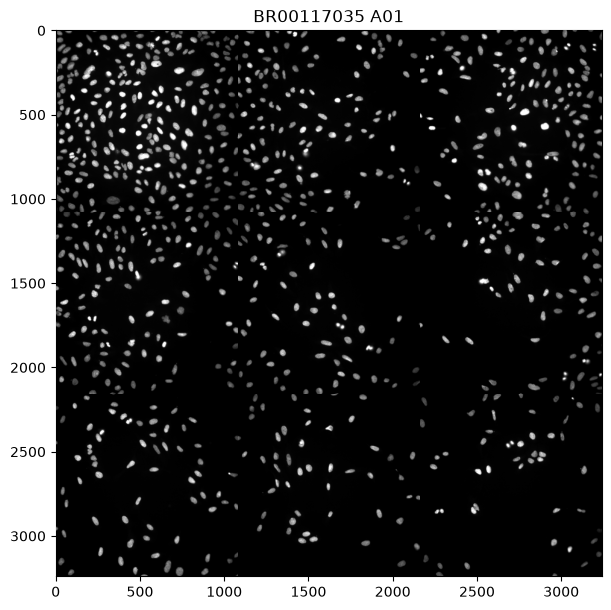

In [3]:
(
    sdata.pl.render_images(**grey(sdata, f"{PLATE}_A01_s1_image")).pl.show(
        coordinate_systems=f"{PLATE}_A01", figsize=(6, 6), title=f"{PLATE} A01"
    )
)

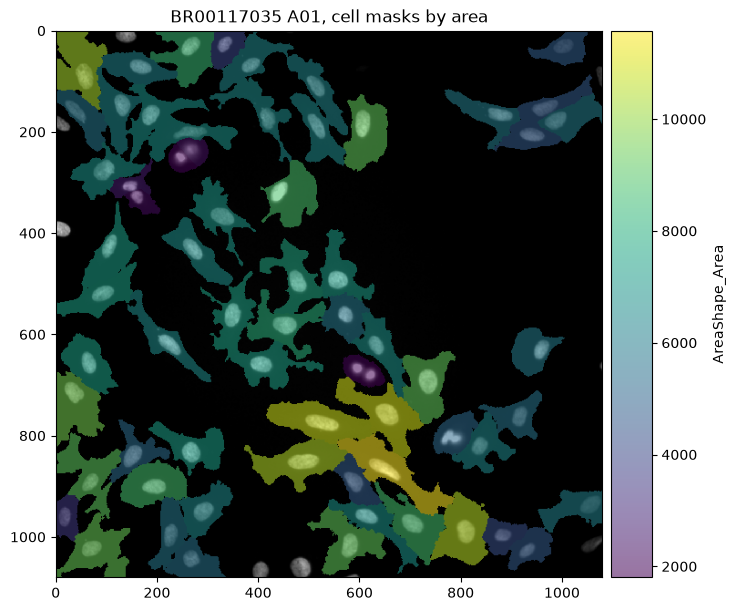

In [4]:
element = f"{PLATE}_A01_s1_image"
(
    sdata.pl.render_images(element, **grey(sdata, element))
    .pl.render_labels(f"{PLATE}_A01_s1_cells", color="AreaShape_Area", table_name="cells", fill_alpha=0.55)
    .pl.show(coordinate_systems=f"{PLATE}_A01_s1", figsize=(6.5, 6), title=f"{PLATE} A01, cell masks by area")
)